In [4]:
# проверка выполнения
# второго закона Кеплера

# подключение библиотеки numpy
import numpy as np

# подключение из библиотеки scipy.integrate
# функции solve_ivp, реализующей
# метод Рунге-Кутты 4-5 порядка
from scipy.integrate import solve_ivp

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt


In [5]:
# Ячейка № 2

# задание функции, возвращающей
# значения координат вектора-функции,
# стоящего в правой части системы ОДУ (4.36)-(4.39)
def Orbit(t, z):
    # инициализация массива, используемого
    # для хранения значений первых производных в (4.36)-(4.39)
    dy = np.zeros(4)

    # вычисление координат вектора-функции,
    # стоящей в правой части (4.30)
    dy[0] = z[1]
    dy[1] = -4 * np.pi**2 * z[0] / (z[0] ** 2 + z[2] ** 2) ** (3 / 2)
    dy[2] = z[3]
    dy[3] = -4 * np.pi**2 * z[2] / (z[0] ** 2 + z[2] ** 2) ** (3 / 2)
    return dy

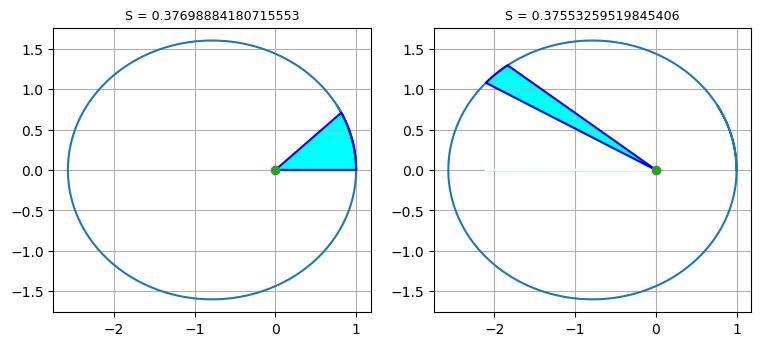

In [ ]:
# Ячейка № 6

# задание начальных условий
x0 = 1
y0 = 0
vx0 = 0
vy0 = 2 * np.pi * 1.2

# задание значения
# начального момента времени
Tstart = 0.0

# задание длительности интервала,
# на котором вычисляется площадь,
# заметаемая радиусом-вектором
# на временном интервале
# [Tstart,Tstart+Tint]
Tint = 0.1

# задание границ интервала,
# на котором ищется
# численное решение системы ОДУ (4.36)-(4.39)
a = 0
b = Tstart + Tint

# задание шага интегрирования
step = 10**-3

# вызов функции, возвращающей
# численное решение системы ОДУ (4.36)-(4.39)
Solv = solve_ivp(Orbit, [a, b], [x0, vx0, y0, vy0], max_step=step)

# перемещение значений координат узлов временной сетки,
# на которой найдены чиcленные решения
# системы ОДУ (4.34)--(4.38), из
# массива Solv.t в массив t
t = Solv.t

# перемещение мгновенных значений
# абсцисс радиуса-вектора в массив х
x = Solv.y[0, :]

# перемещение мгновенных значений
# x-ой составляющей скорости в массив vx
vx = Solv.y[1, :]
# перемещение мгновенных значений
# ординат радиуса-вектора в массив у
y = Solv.y[2, :]

# перемещение мгновенных значений
# у-ой составляющей скорости в массив vy
vy = Solv.y[3, :]

# вычисление площади сектора,
# заметаемого радиусом-вектором
# на временном интервале
# [Tstart,Tstart+Tint]
N = len(t)
s = 0
k = 0
for i in range(N - 1):
    if t[i] >= Tstart:
        if k == 0:
            i_start = i
            k = k + 1
        x1 = np.array([x[i], y[i], 0])
        x2 = np.array([x[i + 1], y[i + 1], 0])
        tmp = np.cross(x1, x2) / 2
        s = s + np.dot(tmp, tmp) ** 0.5

# заносим координаты точек сектора,
# заметенного радиусом-вектором,
# в векторы x1, y1
x1 = x[i_start:N]
y1 = y[i_start:N]

# визуализация орбиты материальной точки
# задание границ временного интервала
a = 0
b = 2.5
# задание шага интегрирования
# вызов функции, возвращающей
# численное решение системы ОДУ (4.36)--(4.39)
Solv = solve_ivp(Orbit, [a, b], [x0, vx0, y0, vy0], max_step=step)

# перемещение координат орбиты в векторы X, Y
X = Solv.y[0, :]
Y = Solv.y[2, :]

fig = plt.figure(figsize=(9, 9))

ax = fig.add_subplot(1, 2, 1)
# визуализируем орбиту материальной точки
ax.plot(X, Y)

# создание векторов x2,y2,
# содержащих координаты притягивающего центра и
# координаты сектора, заметенного радиусом-вектором
N = len(x1)
x2 = np.zeros(N + 2)
y2 = np.zeros(N + 2)
x2[1 : N + 1] = x1
y2[1 : N + 1] = y1

# визуализация сектора, заметенного радиусом-вектором
ax.plot(x2, y2, "b")
ax.fill_between(x2, y2, color="cyan")
x3 = [0, np.min(x2)]
y3 = [0, 0]
ax.plot(x3, y3, color="white")
ax.plot(True)

# визуализация положения притягивающего центра
ax.plot(0, 0, "o")

ax.set_aspect("equal", adjustable="box")

# отображение в заголовке графика
# значения площади сектора
S = "S = " + str(s)
plt.title(S, fontsize=9)
ax.grid(True)

# вычислениие площади сектора,
# для начального момента времени 0.7
Tstart = 0.7

# задание границ интервала,
# на котором ищется
# численное решение системы ОДУ (4.36)-(4.39)
a = 0
b = Tstart + Tint

# задание шага интегрирования
step = 10**-3

# вызов функции, возвращающей
# численное решение системы ОДУ (4.36)-(4.39)
Solv = solve_ivp(Orbit, [a, b], [x0, vx0, y0, vy0], max_step=step)

# перемещение значений координат узлов временной сетки,
# на которой найдены численные решения
# системы ОДУ (4.34)--(4.38), из
# массива Solv.t в массив t

t = Solv.t
# перемещение мгновенных значений
# абсцисс радиуса-вектора в массив х
x = Solv.y[0, :]

# перемещение мгновенных значений
# x-ой составляющей скорости в массив vx
vx = Solv.y[1, :]

# перемещение мгновенных значений
# ординат радиуса-вектора в массив у
y = Solv.y[2, :]

# перемещение мгновенных значений
# у-ой составляющей скорости в массив vy
vy = Solv.y[3, :]

# вычисление площади сектора,
# заметаемого радиусом-вектором
# на временном интервале
# [Tstart,Tstart+Tint]
N = len(t)
s = 0
k = 0
for i in range(N - 1):
    if t[i] >= Tstart:
        if k == 0:
            i_start = i
            k = k + 1
        x1 = np.array([x[i], y[i], 0])
        x2 = np.array([x[i + 1], y[i + 1], 0])
        tmp = np.cross(x1, x2) / 2
        s = s + np.dot(tmp, tmp) ** 0.5

# заносим координаты точек сектора,
# заметенного радиусом-вектором,
# в векторы x1, y1
x1 = x[i_start:N]
y1 = y[i_start:N]

# визуализация орбиты материальной точки
# задание границ временного интервала
a = 0
b = 2.5
# задание шага интегрирования
# вызов функции, возвращающей
# численное решение системы ОДУ (4.36)--(4.39)
Solv = solve_ivp(Orbit, [a, b], [x0, vx0, y0, vy0], max_step=step)

# перемещение координат орбиты в векторы X, Y
X = Solv.y[0, :]
Y = Solv.y[2, :]

ax = fig.add_subplot(1, 2, 2)
# визуализация орбиты материальной точки
ax.plot(X, Y)

# создание векторов x2,y2,
# содержащих координаты притягивающего центра и
# координаты сектора, заметенного радиусом-вектором
N = len(x1)
x2 = np.zeros(N + 2)
y2 = np.zeros(N + 2)
x2[1 : N + 1] = x1
y2[1 : N + 1] = y1

# визуализация сектора, заметенного радиусом-вектором
ax.plot(x2, y2, "b")
ax.fill_between(x2, y2, color="cyan")
x3 = [0, np.min(x2)]
y3 = [0, 0]
ax.plot(x3, y3, color="white")
ax.plot(True)

# визуализация положения притягивающего центра
ax.plot(0, 0, "o")

ax.set_aspect("equal", adjustable="box")

# отображение в заголовке графика
# значения площади сектора
S = "S = " + str(s)
plt.title(S, fontsize=9)
ax.grid(True)

plt.show()